# Fungal sequence length distribution

Histogram of sequence lengths in the FASTA. Switch `FASTA` between the clustered set (what `runner.py` trains on) and the raw reviewed set to see what 40%-identity clustering did. The dashed line is the runner's `length_cutoff`.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

FASTA = Path("../data/fungi_clustered.fasta")   # or ../data/fungi_reviewed.fasta for the pre-cluster set
CUTOFF = 512                                     # runner.py keeps sequences shorter than this

def fasta_lengths(path):
    lengths, n = [], 0
    with open(path) as fh:
        for line in fh:
            if line.startswith(">"):
                if n:
                    lengths.append(n)
                n = 0
            else:
                n += len(line.strip())
        if n:
            lengths.append(n)
    return np.array(lengths)

L = fasta_lengths(FASTA)
print(f"{FASTA.name}: {len(L)} sequences")
print(f"min {L.min()}  median {int(np.median(L))}  mean {L.mean():.0f}  max {L.max()}")
print(f"kept (<{CUTOFF}): {(L < CUTOFF).mean():.1%}  ({(L < CUTOFF).sum()} sequences)")

fungi_clustered.fasta: 16542 sequences
min 3  median 391  mean 497  max 15639
kept (<512): 65.9%  (10894 sequences)


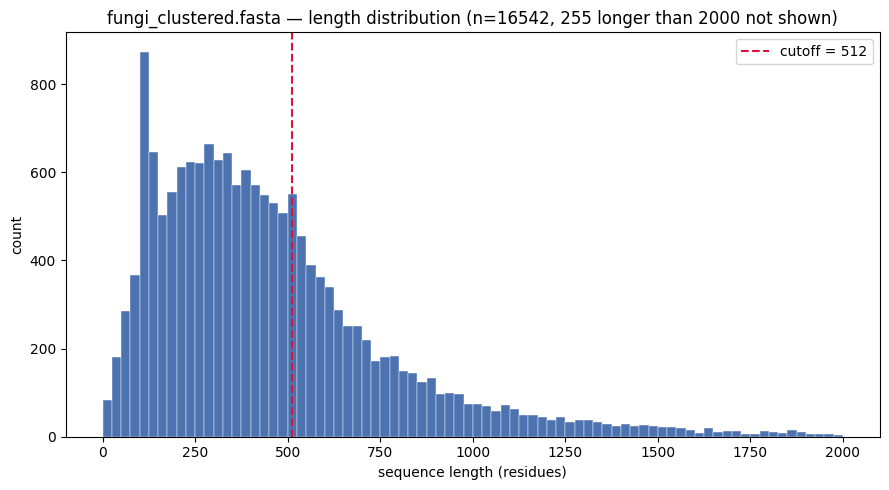

In [ ]:
XMAX = 2000   # clip the long right tail so the bulk is readable
over = (L > XMAX).sum()

plt.figure(figsize=(9, 5))
plt.hist(L, bins=80, range=(0, XMAX), color="#4C72B0", edgecolor="white", linewidth=0.3)
plt.axvline(CUTOFF, color="crimson", linestyle="--", label=f"cutoff = {CUTOFF}")
plt.xlabel("sequence length (residues)")
plt.ylabel("count")
plt.title(f"length distribution")
plt.legend()
plt.tight_layout()
plt.show()